# Choosing `k` for daily outlier removal

Compare the IQR rule with `k = 1.5`, `k = 2`, and `k = 3` for `ABVERKAUFTE_MENGE_KG`.

Outliers are computed per (`ARTIKEL_ID`, `MARKT_ID`) series from `data/interim/transactions_daily_agg`.

## Setup

Import the required libraries, locate the daily aggregate parquet files, and open a DuckDB connection for the remaining analysis.

In [8]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "data" / "interim" / "transactions_daily_agg").exists():
        ROOT = candidate
        break

DATA_DIR = ROOT / "data" / "interim" / "transactions_daily_agg"
DATA_GLOB = DATA_DIR / "transactions_year_*.parquet"
DEMAND_COL = "ABVERKAUFTE_MENGE_KG"
TOP_N = 10

files = sorted(DATA_DIR.glob("transactions_year_*.parquet"))
if not files:
    raise FileNotFoundError(f"No parquet files found in {DATA_DIR}")

def sql_literal(value):
    return "'" + str(value).replace("'", "''") + "'"

con = duckdb.connect()
con.execute("PRAGMA threads=8")

print(f"Reading {len(files)} yearly parquet files from {DATA_DIR}")

Reading 6 yearly parquet files from /Users/vlada/UNI/SoSe2026/ba/ba_code/data/interim/transactions_daily_agg


## Source view

Create a DuckDB view over the yearly daily-aggregate files and check which descriptive columns are available for the later tables and plots.

In [9]:
con.execute(
    f"""
    CREATE OR REPLACE TEMP VIEW source AS
    SELECT *, CAST(DATE AS DATE) AS DATE_D
    FROM read_parquet({sql_literal(DATA_GLOB)})
    """
)

columns = [row[0] for row in con.execute("DESCRIBE SELECT * FROM source").fetchall()]
requested_cols = [
    "ARTIKEL_ID",
    "MARKT_ID",
    "VERKAUFSEINHEIT",
    "ARTIKEL_BEZ",
    "UMS_MENGE",
    "GRAMM_BON",
    "DATE",
    DEMAND_COL,
]
available_cols = [col for col in requested_cols if col in columns]
missing_cols = [col for col in requested_cols if col not in columns]

if missing_cols:
    print("Requested columns not present in the daily aggregate files:", missing_cols)

available_cols

['ARTIKEL_ID',
 'MARKT_ID',
 'VERKAUFSEINHEIT',
 'ARTIKEL_BEZ',
 'UMS_MENGE',
 'GRAMM_BON',
 'DATE',
 'ABVERKAUFTE_MENGE_KG']

## Overall effect of `k = 1.5`, `k = 2`, and `k = 3`

Compute per-series IQR bounds and summarize how many rows would be removed globally for each candidate multiplier.  Percentage of removed rows across all series can be underrepresentative, since some series may experience stronger outlier filtering than other ones. Furthermore, the series are of different length, so relatively small filtering of long series can dominate the result even if shorter series experienced relatively big filtering. For analysis per series, see cells below.

In [10]:
con.execute(
    f"""
    CREATE OR REPLACE TEMP TABLE bounds AS
    WITH q AS (
        SELECT
            ARTIKEL_ID,
            MARKT_ID,
            quantile_cont({DEMAND_COL}, 0.25) AS q1,
            quantile_cont({DEMAND_COL}, 0.75) AS q3
        FROM source
        GROUP BY ARTIKEL_ID, MARKT_ID
    )
    SELECT
        ARTIKEL_ID,
        MARKT_ID,
        q1,
        q3,
        q3 - q1 AS iqr,
        q3 + 1.5 * (q3 - q1) AS upper_k15,
        q3 + 2 * (q3 - q1) AS upper_k2,
        q3 + 3 * (q3 - q1) AS upper_k3
    FROM q
    """
)

summary = con.execute(
    f"""
    SELECT
        COUNT(*) AS rows_total,
        SUM(CASE WHEN s.{DEMAND_COL} > b.upper_k15 THEN 1 ELSE 0 END) AS rows_removed_k15,
        SUM(CASE WHEN s.{DEMAND_COL} > b.upper_k2 THEN 1 ELSE 0 END) AS rows_removed_k2,
        SUM(CASE WHEN s.{DEMAND_COL} > b.upper_k3 THEN 1 ELSE 0 END) AS rows_removed_k3
    FROM source s
    JOIN bounds b USING (ARTIKEL_ID, MARKT_ID)
    """
).df()

summary["pct_removed_k15"] = summary["rows_removed_k15"] / summary["rows_total"] * 100
summary["pct_removed_k2"] = summary["rows_removed_k2"] / summary["rows_total"] * 100
summary["pct_removed_k3"] = summary["rows_removed_k3"] / summary["rows_total"] * 100
summary

,rows_total,rows_removed_k15,rows_removed_k2,rows_removed_k3,pct_removed_k15,pct_removed_k2,pct_removed_k3
0,2244017,137545.0,93680.0,48894.0,6.12941,4.174656,2.17886


## CV before and after outlier removal

Compute the coefficient of variation (`stddev_samp / mean`) per product-store series before filtering and after applying each candidate `k`, then compare the resulting CV distributions.

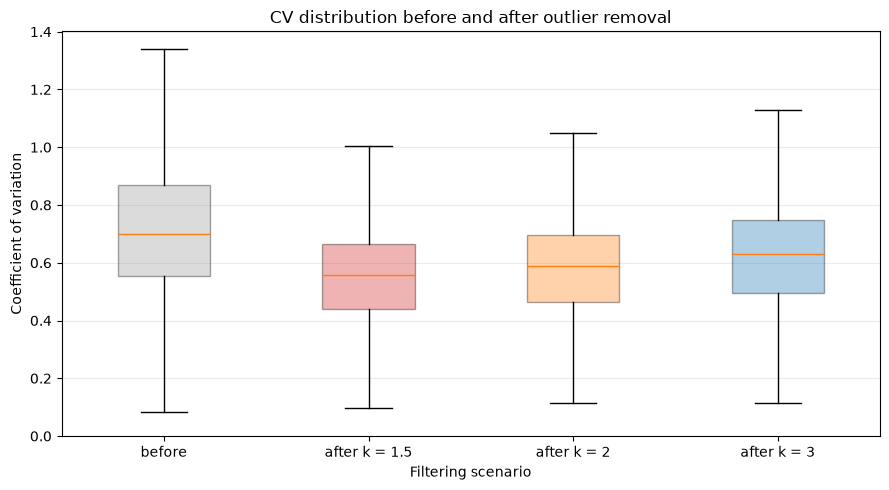

In [12]:
cv_by_k = con.execute(
    f"""
    SELECT
        s.ARTIKEL_ID,
        s.MARKT_ID,
        stddev_samp(s.{DEMAND_COL}) / NULLIF(avg(s.{DEMAND_COL}), 0) AS cv_before,
        stddev_samp(CASE WHEN s.{DEMAND_COL} <= b.upper_k15 THEN s.{DEMAND_COL} END)
            / NULLIF(avg(CASE WHEN s.{DEMAND_COL} <= b.upper_k15 THEN s.{DEMAND_COL} END), 0) AS cv_after_k15,
        stddev_samp(CASE WHEN s.{DEMAND_COL} <= b.upper_k2 THEN s.{DEMAND_COL} END)
            / NULLIF(avg(CASE WHEN s.{DEMAND_COL} <= b.upper_k2 THEN s.{DEMAND_COL} END), 0) AS cv_after_k2,
        stddev_samp(CASE WHEN s.{DEMAND_COL} <= b.upper_k3 THEN s.{DEMAND_COL} END)
            / NULLIF(avg(CASE WHEN s.{DEMAND_COL} <= b.upper_k3 THEN s.{DEMAND_COL} END), 0) AS cv_after_k3
    FROM source s
    JOIN bounds b USING (ARTIKEL_ID, MARKT_ID)
    GROUP BY s.ARTIKEL_ID, s.MARKT_ID
    """
).df()

cv_plot_cols = {
    "before": "cv_before",
    "after k = 1.5": "cv_after_k15",
    "after k = 2": "cv_after_k2",
    "after k = 3": "cv_after_k3",
}
cv_boxplot_data = [cv_by_k[col].dropna() for col in cv_plot_cols.values()]

fig, ax = plt.subplots(figsize=(9, 5))
box = ax.boxplot(
    cv_boxplot_data,
    tick_labels=list(cv_plot_cols.keys()),
    showfliers=False,
    patch_artist=True,
)
for patch, color in zip(box["boxes"], ["0.6", "tab:red", "tab:orange", "tab:blue"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)

ax.set_title("CV distribution before and after outlier removal")
ax.set_xlabel("Filtering scenario")
ax.set_ylabel("Coefficient of variation")
ax.set_ylim(bottom=0)
ax.grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Median CV and row-removal effect by `k`

Summarize the filtering effect in one table using one shared population per `k`: only series with valid positive `cv_before` and valid `cv_after_k` are used for the CV-reduction median, the median percentage of rows removed, and the percentage of affected series.

The coefficient of variation is calculated as `CV = stddev_samp(ABVERKAUFTE_MENGE_KG) / mean(ABVERKAUFTE_MENGE_KG)`. The reduction is calculated per series as `100 * (cv_before - cv_after_k) / cv_before`.

`median rows removed, %` is also calculated per series first as `100 * rows_removed_in_series / rows_total_in_series`, then summarized with the median across valid series. This avoids longer series dominating the comparison.

`% affected series` is the share of valid series with at least one row removed for the given `k`. Series with `CV = 0` are excluded from all three summary columns because they have no standard deviation, so there is no variation-driven outlier to remove. If the mean were `0` while the standard deviation were positive, CV would be undefined rather than `0`; this is not the case here because the transaction quantities used in this notebook are positive.

In [27]:
per_series_removed = con.execute(
    f"""
    SELECT
        s.ARTIKEL_ID,
        s.MARKT_ID,
        COUNT(*) AS rows_total,
        SUM(CASE WHEN s.{DEMAND_COL} > b.upper_k15 THEN 1 ELSE 0 END) AS rows_removed_k15,
        SUM(CASE WHEN s.{DEMAND_COL} > b.upper_k2 THEN 1 ELSE 0 END) AS rows_removed_k2,
        SUM(CASE WHEN s.{DEMAND_COL} > b.upper_k3 THEN 1 ELSE 0 END) AS rows_removed_k3,
        100.0 * SUM(CASE WHEN s.{DEMAND_COL} > b.upper_k15 THEN 1 ELSE 0 END) / COUNT(*) AS pct_removed_k15,
        100.0 * SUM(CASE WHEN s.{DEMAND_COL} > b.upper_k2 THEN 1 ELSE 0 END) / COUNT(*) AS pct_removed_k2,
        100.0 * SUM(CASE WHEN s.{DEMAND_COL} > b.upper_k3 THEN 1 ELSE 0 END) / COUNT(*) AS pct_removed_k3
    FROM source s
    JOIN bounds b USING (ARTIKEL_ID, MARKT_ID)
    GROUP BY s.ARTIKEL_ID, s.MARKT_ID
    """
).df()

cv_effect = cv_by_k.merge(
    per_series_removed[
        [
            "ARTIKEL_ID",
            "MARKT_ID",
            "pct_removed_k15",
            "pct_removed_k2",
            "pct_removed_k3",
        ]
    ],
    on=["ARTIKEL_ID", "MARKT_ID"],
    how="inner",
)

k_summary_specs = [
    (1.5, "cv_after_k15", "pct_removed_k15"),
    (2.0, "cv_after_k2", "pct_removed_k2"),
    (3.0, "cv_after_k3", "pct_removed_k3"),
]

summary_rows = []
for k, cv_col, rows_col in k_summary_specs:
    valid_k = cv_effect.loc[
        cv_effect["cv_before"].notna()
        & (cv_effect["cv_before"] > 0)
        & cv_effect[cv_col].notna()
    ].copy()
    valid_k["cv_reduction_pct"] = (
        100.0 * (valid_k["cv_before"] - valid_k[cv_col]) / valid_k["cv_before"]
    )
    summary_rows.append(
        {
            "k": k,
            "median cv reduction, %": valid_k["cv_reduction_pct"].median(),
            "median rows removed, %": valid_k[rows_col].median(),
            "affected series, %": 100.0 * (valid_k[rows_col] > 0).mean(),
        }
    )

cv_reduction_by_k = pd.DataFrame(summary_rows)

cv_reduction_by_k = cv_reduction_by_k.round(
    {
        "median cv reduction, %": 2,
        "median rows removed, %": 2,
        "affected series, %": 2,
    }
)
cv_reduction_by_k

,k,"median cv reduction, %","median rows removed, %","affected series, %"
0,1.5,18.25,4.97,73.73
1,2.0,12.55,2.60,66.44
2,3.0,3.15,0.38,52.89


## Ten product/store series with the biggest outlier rows

The table keeps one biggest outlier row per (`ARTIKEL_ID`, `MARKT_ID`) series, ranked by the excess over the `k = 1.5` upper bound.

In [13]:
select_cols = ",\n            ".join(f"s.{col}" for col in available_cols)

top_outliers = con.execute(
    f"""
    WITH outlier_rows AS (
        SELECT
            {select_cols},
            b.q1,
            b.q3,
            b.iqr,
            b.upper_k15,
            b.upper_k2,
            b.upper_k3,
            s.{DEMAND_COL} - b.upper_k15 AS excess_k15,
            s.{DEMAND_COL} - b.upper_k2 AS excess_k2,
            s.{DEMAND_COL} - b.upper_k3 AS excess_k3,
            s.{DEMAND_COL} > b.upper_k15 AS outlier_k15,
            s.{DEMAND_COL} > b.upper_k2 AS outlier_k2,
            s.{DEMAND_COL} > b.upper_k3 AS outlier_k3,
            ROW_NUMBER() OVER (
                PARTITION BY s.ARTIKEL_ID, s.MARKT_ID
                ORDER BY s.{DEMAND_COL} - b.upper_k15 DESC
            ) AS series_rank
        FROM source s
        JOIN bounds b USING (ARTIKEL_ID, MARKT_ID)
        WHERE s.{DEMAND_COL} > b.upper_k15
    )
    SELECT * EXCLUDE (series_rank)
    FROM outlier_rows
    WHERE series_rank = 1
    ORDER BY excess_k15 DESC
    LIMIT {TOP_N}
    """
).df()

top_outliers

,ARTIKEL_ID,MARKT_ID,VERKAUFSEINHEIT,ARTIKEL_BEZ,UMS_MENGE,GRAMM_BON,DATE,ABVERKAUFTE_MENGE_KG,q1,q3,iqr,upper_k15,upper_k2,upper_k3,excess_k15,excess_k2,excess_k3,outlier_k15,outlier_k2,outlier_k3
0,316810,1300023,kg,Schweinenacken mit Knochen am Stück,685.733,685.733,2022-11-24,685.733,1.53050,55.85900,54.3285,137.35175,164.51600,218.84450,548.38125,521.21700,466.88850,True,True,True
1,220433,1300023,kg,Frico Gouda jung 48% Fett i..Tr.,274.489,274.489,2022-11-24,274.489,0.36300,6.63500,6.2720,16.04300,19.17900,25.45100,258.44600,255.31000,249.03800,True,True,True
2,318072,1100045,kg,"Paradies-Kotelett mariniert, aus dem Schweinenacken",253.499,253.499,2024-04-13,253.499,1.04200,10.15400,9.1120,23.82200,28.37800,37.49000,229.67700,225.12100,216.00900,True,True,True
3,316623,1300021,kg,Hackfleisch gemischt Schwein und Rind,295.569,295.569,2025-04-14,295.569,21.62775,56.92775,35.3000,109.87775,127.52775,162.82775,185.69125,168.04125,132.74125,True,True,True
4,911705,1300021,kg,Frankreich Rinderrouladen Oberschale,210.854,210.854,2024-12-23,210.854,1.33650,11.12900,9.7925,25.81775,30.71400,40.50650,185.03625,180.14000,170.34750,True,True,True
5,317123,1100045,kg,"Nackensteak mariniert, vom Schwein",219.230,219.230,2025-04-19,219.230,2.24000,15.25000,13.0100,34.76500,41.27000,54.28000,184.46500,177.96000,164.95000,True,True,True
6,317123,1300021,kg,"Nackensteak mariniert, vom Schwein",242.283,242.283,2022-04-16,242.283,3.57000,26.24650,22.6765,60.26125,71.59950,94.27600,182.02175,170.68350,148.00700,True,True,True
7,317123,1300004,kg,"Nackensteak mariniert, vom Schwein",229.695,229.695,2025-04-30,229.695,3.38600,22.58200,19.1960,51.37600,60.97400,80.17000,178.31900,168.72100,149.52500,True,True,True
8,911705,1300024,kg,Frankreich Rinderrouladen Oberschale,165.585,165.585,2024-12-23,165.585,1.29850,8.13300,6.8345,18.38475,21.80200,28.63650,147.20025,143.78300,136.94850,True,True,True
9,911705,1300004,kg,Frankreich Rinderrouladen Oberschale,148.157,148.157,2024-12-23,148.157,1.28500,7.92100,6.6360,17.87500,21.19300,27.82900,130.28200,126.96400,120.32800,True,True,True


## Raw series vs after removing outliers

Plot the highest-impact product-store series with each candidate cutoff.

,store_label,ARTIKEL_ID,MARKT_ID,ARTIKEL_BEZ,VERKAUFSEINHEIT
0,Store A,220433,1300023,Frico Gouda jung 48% Fett i..Tr.,kg
1,Store B,316623,1300021,Hackfleisch gemischt Schwein und Rind,kg
2,Store C,316810,1300023,Schweinenacken mit Knochen am Stück,kg
3,Store D,317123,1100045,"Nackensteak mariniert, vom Schwein",kg
4,Store E,317123,1300004,"Nackensteak mariniert, vom Schwein",kg
5,Store F,317123,1300021,"Nackensteak mariniert, vom Schwein",kg
6,Store G,318072,1100045,"Paradies-Kotelett mariniert, aus dem Schweinenacken",kg
7,Store H,911705,1300004,Frankreich Rinderrouladen Oberschale,kg
8,Store I,911705,1300021,Frankreich Rinderrouladen Oberschale,kg
9,Store J,911705,1300024,Frankreich Rinderrouladen Oberschale,kg


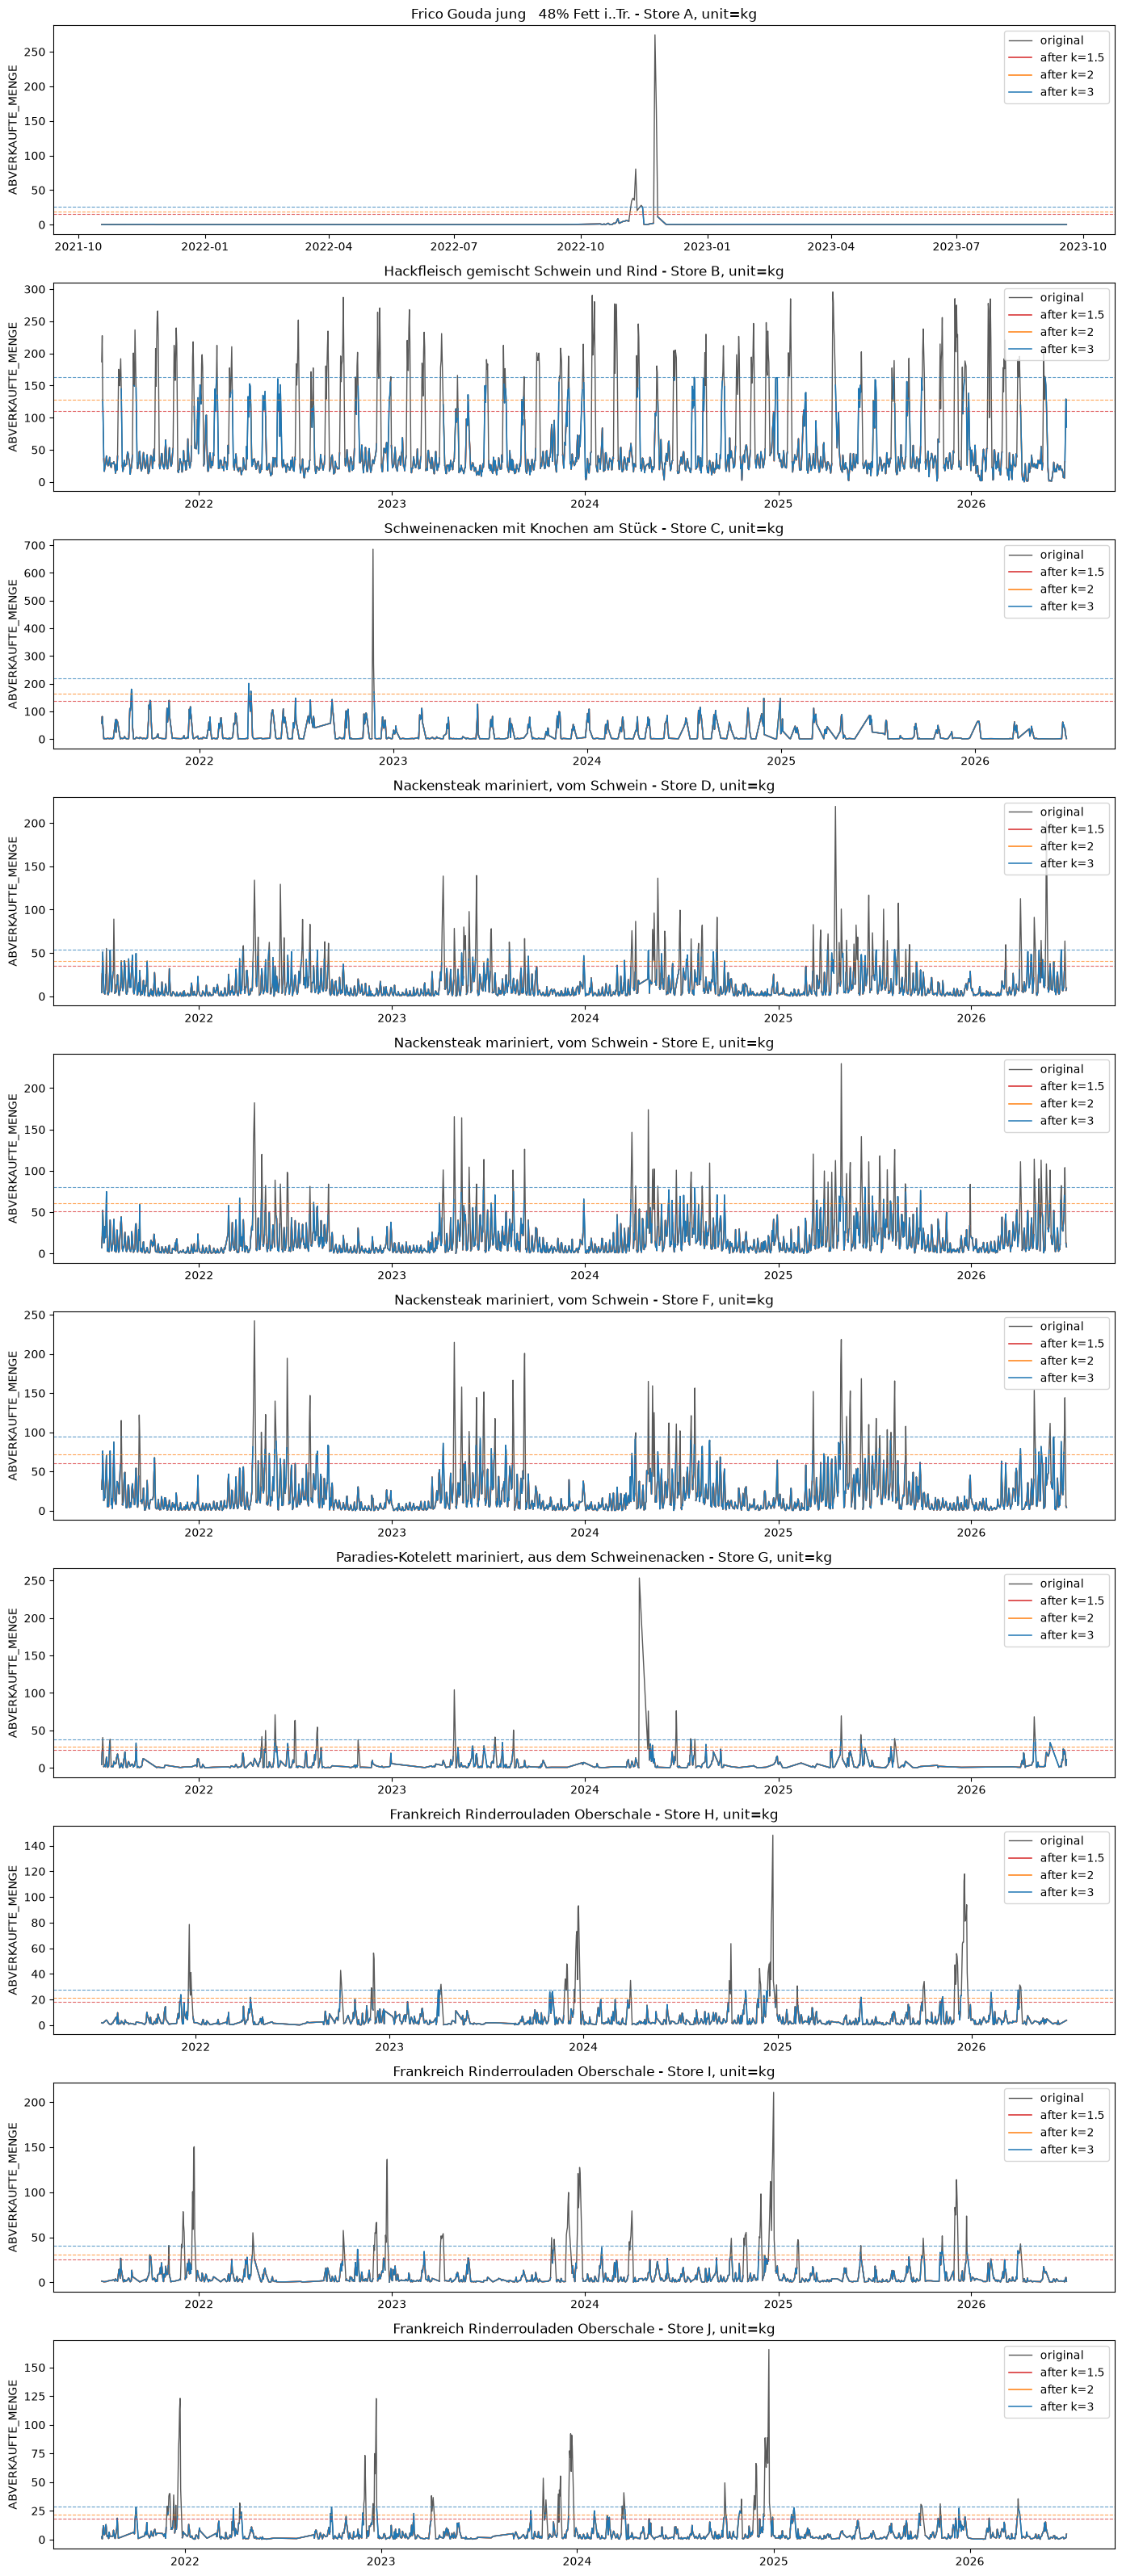

In [26]:
if top_outliers.empty:
    raise ValueError("No outliers found with k = 1.5.")

top_series = top_outliers[["ARTIKEL_ID", "MARKT_ID"]].copy()
con.register("top_series", top_series)

plot_df = con.execute(
    f"""
    SELECT
        s.ARTIKEL_ID,
        s.MARKT_ID,
        s.DATE_D AS DATE,
        s.{DEMAND_COL},
        s.ARTIKEL_BEZ,
        s.VERKAUFSEINHEIT,
        b.upper_k15,
        b.upper_k2,
        b.upper_k3
    FROM source s
    JOIN top_series ts USING (ARTIKEL_ID, MARKT_ID)
    JOIN bounds b USING (ARTIKEL_ID, MARKT_ID)
    ORDER BY s.ARTIKEL_ID, s.MARKT_ID, s.DATE_D
    """
).df()

plot_df["DATE"] = pd.to_datetime(plot_df["DATE"])
plot_df["after_k15"] = plot_df[DEMAND_COL].where(plot_df[DEMAND_COL] <= plot_df["upper_k15"])
plot_df["after_k2"] = plot_df[DEMAND_COL].where(plot_df[DEMAND_COL] <= plot_df["upper_k2"])
plot_df["after_k3"] = plot_df[DEMAND_COL].where(plot_df[DEMAND_COL] <= plot_df["upper_k3"])

groups = list(plot_df.groupby(["ARTIKEL_ID", "MARKT_ID"], sort=False))
store_labels = {
    key: f"Store {chr(ord('A') + idx)}"
    for idx, (key, _) in enumerate(groups)
}

example_series_lookup = pd.DataFrame(
    [
        {
            "store_label": store_labels[(artikel_id, markt_id)],
            "ARTIKEL_ID": artikel_id,
            "MARKT_ID": markt_id,
            "ARTIKEL_BEZ": str(df["ARTIKEL_BEZ"].iloc[0]),
            "VERKAUFSEINHEIT": df["VERKAUFSEINHEIT"].iloc[0],
        }
        for (artikel_id, markt_id), df in groups
    ]
)
display(example_series_lookup)

fig, axes = plt.subplots(len(groups), 1, figsize=(14, 3.2 * len(groups)), sharex=False)
if len(groups) == 1:
    axes = [axes]

for ax, ((artikel_id, markt_id), df) in zip(axes, groups):
    title = str(df["ARTIKEL_BEZ"].iloc[0])[:90]
    store_label = store_labels[(artikel_id, markt_id)]
    unit = df["VERKAUFSEINHEIT"].iloc[0]

    ax.plot(df["DATE"], df[DEMAND_COL], color="0.35", linewidth=1.0, label="original")
    ax.plot(df["DATE"], df["after_k15"], color="tab:red", linewidth=1.1, label="after k=1.5")
    ax.plot(df["DATE"], df["after_k2"], color="tab:orange", linewidth=1.1, label="after k=2")
    ax.plot(df["DATE"], df["after_k3"], color="tab:blue", linewidth=1.1, label="after k=3")
    ax.axhline(df["upper_k15"].iloc[0], color="tab:red", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.axhline(df["upper_k2"].iloc[0], color="tab:orange", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.axhline(df["upper_k3"].iloc[0], color="tab:blue", linestyle="--", linewidth=0.8, alpha=0.7)

    ax.set_title(f"{title} - {store_label}, unit={unit}")
    ax.set_ylabel(DEMAND_COL)
    ax.legend(loc="upper right")

plt.tight_layout()